In [1]:
!nvidia-smi

Sun Oct  5 19:48:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:03:00.0 Off |                    0 |
| N/A   30C    P0             51W /  400W |       1MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear

import tensorflow_probability.substrates.jax as tfp
import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
tfd = tfp.distributions

from corner import corner

/global/common/software/deepsrch/jax_gigalens_kernel/jax-gigalens/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.25), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 3),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.05), gamma2=tfd.Normal(0, 0.05))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(2, 6),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
                Ie=tfd.LogNormal(jnp.log(500.0), 0.3),
            )
        ),
        # tfd.JointDistributionNamed(
        #     dict(
        #         R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
        #         n_sersic=tfd.Uniform(2, 6),
        #         e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
        #         e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
        #         center_x=tfd.Normal(0, 0.05),
        #         center_y=tfd.Normal(0, 0.05),
        #         Ie=tfd.LogNormal(jnp.log(500.0), 0.3),
        #     )
        # )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.25),
                center_y=tfd.Normal(0, 0.25),
                Ie=tfd.LogNormal(jnp.log(150.0), 0.5),
            )
        ),
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.25),
                center_y=tfd.Normal(0, 0.25),
                Ie=tfd.LogNormal(jnp.log(150.0), 0.5),
            )
        )
    ]
)

prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

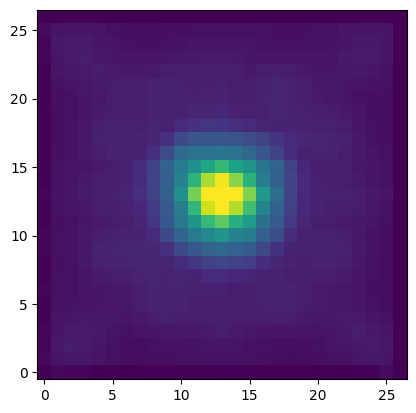

In [4]:
from astropy.io import fits
from astropy.visualization import simple_norm
# replace with your file
f=fits.open('../desi238/psf238.fits') 
imR=f[0].data
f.close()
# imR[imR<0]=0
norm = simple_norm(imR, 'sqrt', percent=99.)
plt.imshow(imR, norm=norm, origin='lower', cmap='viridis')


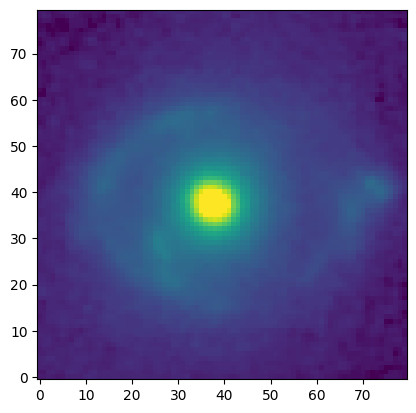

In [5]:
from astropy.io import fits
from astropy.visualization import simple_norm
# replace with your file
f=fits.open('../desi238/desi238.fits') 
imR=f[1].data[1030:1110, 1185:1265]
img = f[1].data
f.close()
# imR[imR<0]=0
norm = simple_norm(imR, 'sqrt', percent=99.)
plt.imshow(imR, norm=norm, origin='lower', cmap='viridis')


0.012595171

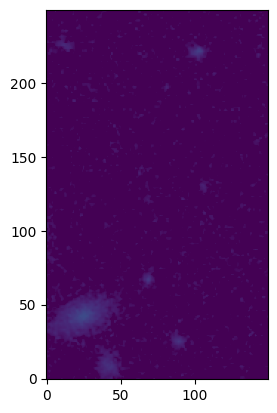

In [6]:
plt.imshow(img[len(img)-750:len(img)-500, 700:850], norm=norm, origin='lower', cmap='viridis')
squared_elements = np.square(img[len(img)-750:len(img)-500, 700:850])

# 2. Calculate the mean of the squared elements
mean_squared = np.mean(squared_elements)

# 3. Take the square root of the mean squared
rms_value = np.sqrt(mean_squared)

rms_value

In [7]:
# kernel = np.load('./gigalens/assets/psf.npy').astype(np.float32)
f = fits.open('../desi238/psf238.fits')
kernel = f[0].data
f.close()
# kernel[kernel<0]=0

# need to change num_pix?
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=80, supersample=2, kernel=kernel)
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], 
                           [sersic.SersicEllipse(use_lstsq=False)], 
                           [sersic.SersicEllipse(use_lstsq=False), sersic.SersicEllipse(use_lstsq=False)]
                          )
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
# observed_img = np.load('./gigalens/assets/demo.npy')
f = fits.open('../desi238/desi238.fits')
observed_img = f[1].data[1030:1110, 1185:1265]
f.close()
# observed_img[observed_img<0]=0

background_rms, exp_time = rms_value, 100
prob_model = ForwardProbModel(prior, observed_img, background_rms, exp_time)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

In [8]:
schedule_fn = optax.polynomial_schedule(init_value=-1e-2, end_value=-1e-2/3, 
                                      power=0.5, transition_steps=500)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
map_estimate = model_seq.MAP(opt, seed=0)

Chi-squared: 0.944: 100%|██████████| 350/350 [00:30<00:00, 11.55it/s] 


In [9]:
lps = prob_model.log_prob(LensSimulator(phys_model, sim_config, bs=500), map_estimate)[0]
best = map_estimate[jnp.argmax(lps)][jnp.newaxis,:]

In [10]:
schedule_fn = optax.polynomial_schedule(init_value=-1e-6, end_value=-3e-3, 
                                      power=2, transition_steps=300)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
qz, loss_hist = model_seq.SVI(best, opt, n_vi=1000, num_steps=2500)

ELBO: -14766.690: 100%|██████████| 2500/2500 [03:25<00:00, 12.17it/s]


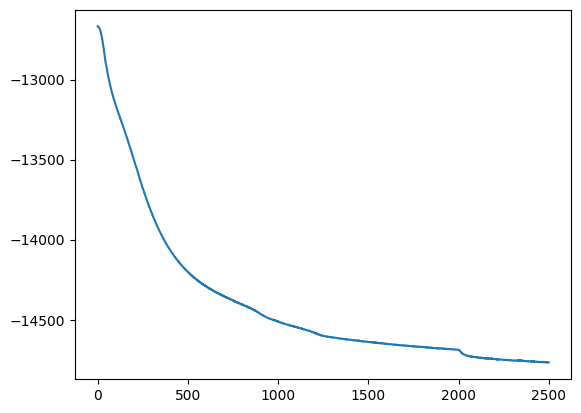

In [11]:
plt.plot(loss_hist)

In [12]:
samples = model_seq.HMC(qz, num_burnin_steps=250, num_results=750)

Sampling took 59.7s


In [13]:
# rhat= tfp.mcmc.potential_scale_reduction(jnp.transpose(samples.all_states, (1,2,0,3)), independent_chain_ndims=2)

In [14]:
rhat= tfp.mcmc.potential_scale_reduction(jnp.transpose(samples.all_states, (1,2,0,3)), independent_chain_ndims=2)
ess = tfp.mcmc.effective_sample_size(jnp.transpose(samples.all_states, (1,2,0,3)), cross_chain_dims=[1,2])
numParams = len(rhat)
for i in range(0,numParams):
    print(rhat[i], ess[i])

1.0055993 8546.441
1.0114108 4502.523
1.0065033 5983.3027
1.0094485 5954.495
1.0126328 3327.585
1.0024519 14407.575
1.0028493 12241.251
1.0070052 6568.798
1.163296 362.27698
1.1462439 401.9745
1.0070853 28811.135
1.019969 25159.229
1.0045121 28376.342
1.0040977 26651.766
1.4409784 158.63385
1.0084563 4654.723
1.0003623 24842.451
1.0010296 15454.344
1.0070398 7536.9736
1.0034283 7619.121
1.0015273 13656.552
1.0190269 1334.1833
1.0917664 629.8789
1.0148662 3333.4768
1.0086166 4265.2676
1.0102209 4402.5522
1.00288 25342.848
1.0035903 25091.715
1.1855383 309.84647


In [15]:
rhat

Array([1.0055993, 1.0114108, 1.0065033, 1.0094485, 1.0126328, 1.0024519,
       1.0028493, 1.0070052, 1.163296 , 1.1462439, 1.0070853, 1.019969 ,
       1.0045121, 1.0040977, 1.4409784, 1.0084563, 1.0003623, 1.0010296,
       1.0070398, 1.0034283, 1.0015273, 1.0190269, 1.0917664, 1.0148662,
       1.0086166, 1.0102209, 1.00288  , 1.0035903, 1.1855383],      dtype=float32)

In [16]:
priorObjects = [['EPL', 'SHEAR'], ['SERSIC_ELLIPSE'], ['SERSIC_ELLIPSE', 'SERSIC_ELLIPSE']]
smp = jnp.transpose(samples.all_states, (1,2,0,3)).reshape((-1, 22+7))
smp_physical = prob_model.bij.forward(list(smp.T))

stack = []
for ii, priorSet in enumerate(priorObjects):
    for iii, priorObject in enumerate(priorSet):
        if priorObject == "EPL":
            stack.extend([
                            smp_physical[ii][iii]["center_x"],
                            smp_physical[ii][iii]["center_y"],
                            smp_physical[ii][iii]["e1"],
                            smp_physical[ii][iii]["e2"],
                            smp_physical[ii][iii]["gamma"],
                            smp_physical[ii][iii]["theta_E"],
            ])
        elif priorObject == "SHEAR":
            stack.extend([
                            smp_physical[ii][iii]["gamma1"],
                            smp_physical[ii][iii]["gamma2"],
            ])
        elif priorObject == "SERSIC_ELLIPSE":
            stack.extend([
                            smp_physical[ii][iii]["R_sersic"],
                            smp_physical[ii][iii]["center_x"],
                            smp_physical[ii][iii]["center_y"],
                            smp_physical[ii][iii]["e1"],
                            smp_physical[ii][iii]["e2"],
                            smp_physical[ii][iii]["n_sersic"],
                            smp_physical[ii][iii]["Ie"],
            ])
        elif priorObject == "SHAPELETS":
            stack.extend([
                            smp_physical[ii][iii]["beta"],
                            smp_physical[ii][iii]["center_x"],
                            smp_physical[ii][iii]["center_y"],
            ])
        elif priorObject == "SIS":
            stack.extend([
                            smp_physical[ii][iii]["center_x"],
                            smp_physical[ii][iii]["center_y"],
                            smp_physical[ii][iii]["theta_E"],
                            smp_physical[ii][iii]["Ie"],
            ])
            
get_samples = np.column_stack(stack)
physical_samples = get_samples

reversed_physical_samples = np.zeros([len(physical_samples[:,0]),22+7])
reversed_physical_samples[:,0:6]=np.flip(physical_samples[:,0:6])
reversed_physical_samples[:,6:8]=np.flip(physical_samples[:,6:8])
reversed_physical_samples[:,8:22+7] = physical_samples[:,8:22+7]

best_HMC=prob_model.pack_bij.forward(np.median(physical_samples,axis=0).tolist())

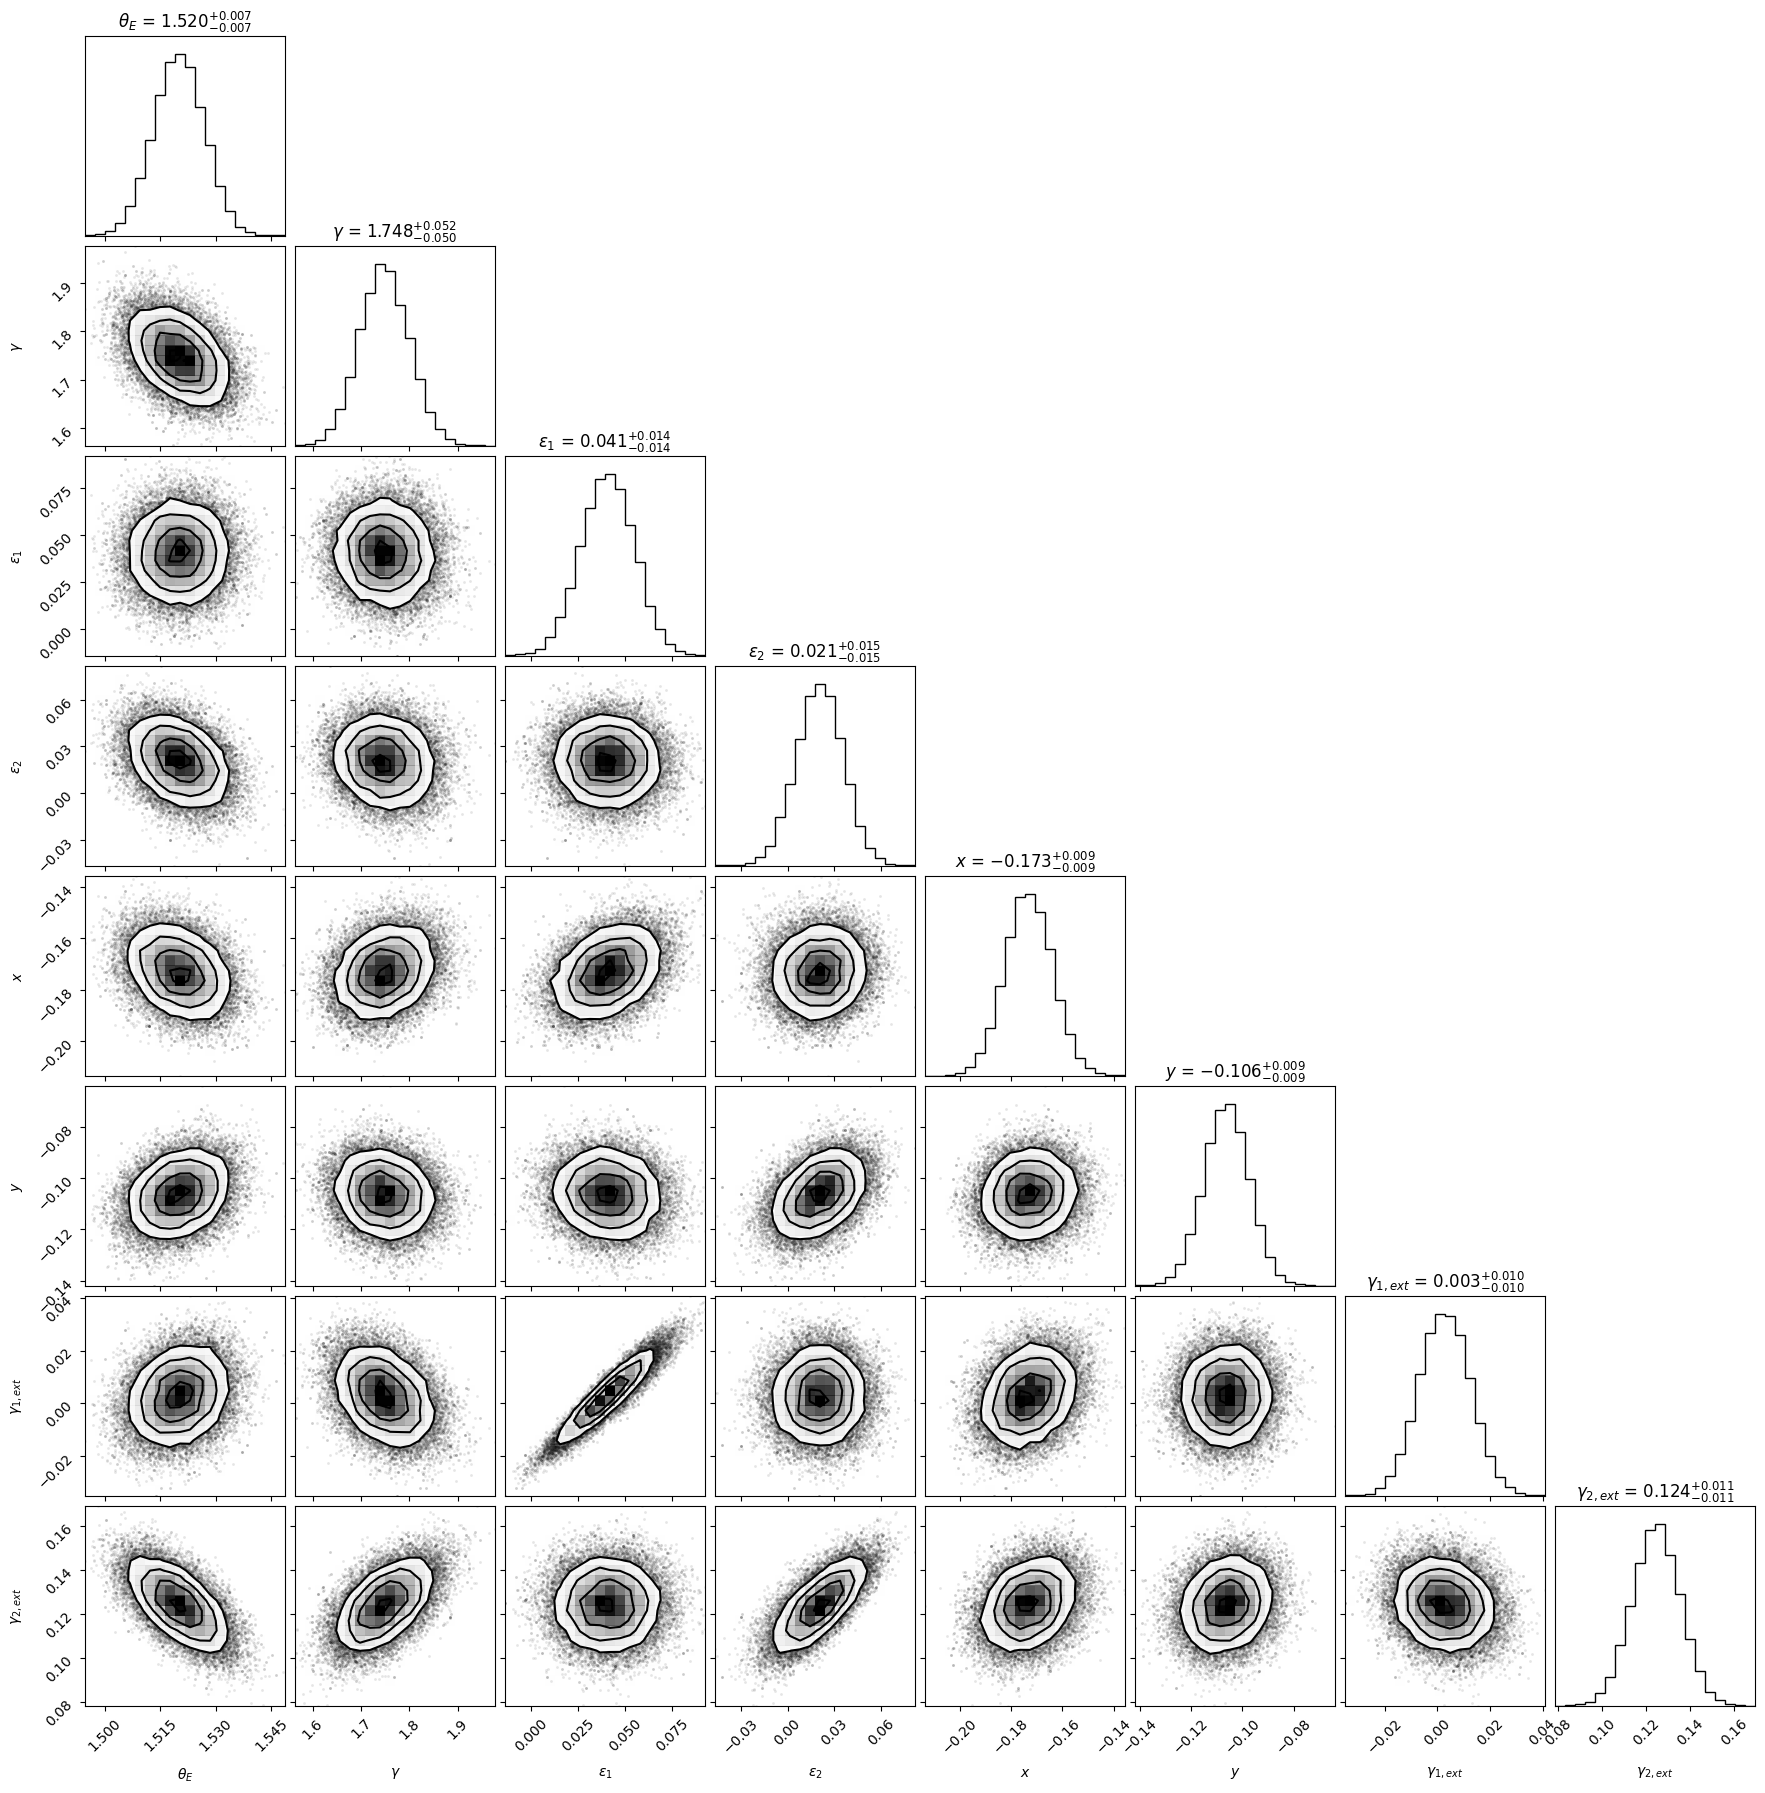

In [17]:
plt.style.use('default')

labels=[r'$\theta_E$', 
        r'$\gamma$', 
        r'$\epsilon_1$', 
        r'$\epsilon_2$', 
        r'$x$', r'$y$', 
        r'$\gamma_{1,ext}$', 
        r'$\gamma_{2,ext}$']

fig = corner(reversed_physical_samples[:,0:8], show_titles=True, title_fmt='.3f', labels=labels)

In [18]:
smp = jnp.transpose(samples.all_states, (1, 2, 0, 3)).reshape((-1, numParams))
smp_physical = prob_model.bij.forward(list(smp.T))

def get_corner_samples(physical, key):
    """
    Key tells you lens_mass (1), lens_light (2), or source_light (3)
    """
    return_list = []

    if key == 1:
        for i in physical[0][0].keys():
            return_list.append(physical[0][0][i])
        for j in physical[0][1].keys():
            return_list.append(physical[0][1][j])

    if key == 2:
        for i in physical[1][0].keys():
            return_list.append(physical[1][0][i])

    if key == 3:
        for i in physical[2][0].keys():
            return_list.append(physical[2][0][i])
            
    return np.stack(return_list).T

mass_samps = get_corner_samples(smp_physical, 1)
median_params = [
    [
        {key: np.median(value) for key, value in d.items()}
        for d in list_of_dicts
    ]
    for list_of_dicts in smp_physical
]
import pprint
pprint.pprint(median_params)

[[{'center_x': -0.10618354,
   'center_y': -0.17318338,
   'e1': 0.020509493,
   'e2': 0.04061756,
   'gamma': 1.7479306,
   'theta_E': 1.5199986},
  {'gamma1': 0.12447405, 'gamma2': 0.0027416183}],
 [{'Ie': 25.30426,
   'R_sersic': 1.520651,
   'center_x': -0.117984146,
   'center_y': -0.121879295,
   'e1': -0.044922844,
   'e2': 0.052381948,
   'n_sersic': 5.7904186}],
 [{'Ie': 88.717545,
   'R_sersic': 0.17235124,
   'center_x': 0.023968022,
   'center_y': 1.485815,
   'e1': 0.0016930997,
   'e2': 0.01257506,
   'n_sersic': 0.56299496},
  {'Ie': 32.237034,
   'R_sersic': 0.18104626,
   'center_x': 0.12700433,
   'center_y': -0.11475117,
   'e1': 0.18450987,
   'e2': 0.33170196,
   'n_sersic': 0.65263}]]


Chi-square: 0.24954705


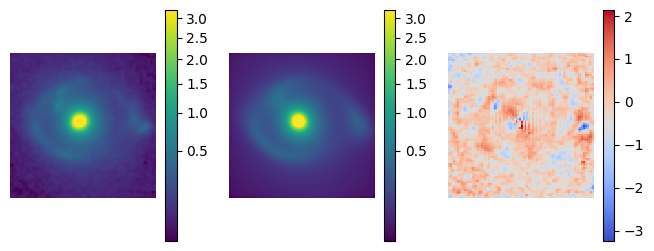

In [19]:
import matplotlib as mpl

norm = simple_norm(imR, 'sqrt', percent=99.)

plt.figure(figsize=(8, 3))
plt.subplot(131)
plt.imshow(observed_img, norm=norm)
plt.colorbar()
plt.axis('off')

plt.subplot(132)
simulated = lens_sim.simulate(median_params)
plt.imshow(simulated, norm=norm)
plt.colorbar()
plt.axis('off')

plt.subplot(133)
resid = simulated - np.array(observed_img, dtype='f4')

err_map = np.sqrt(background_rms**2 + simulated/exp_time)
plt.imshow(resid/err_map, cmap='coolwarm', interpolation='none', )
print('Chi-square:', np.mean((resid/err_map)**2))
plt.axis('off')
plt.colorbar()